# Deep CNNs for Palm Fruit Maturity Classification — Colab reproduction

Reproduction of **Han & Yi, "Deep Convolutional Neural Networks for Palm Fruit Maturity Classification" (arXiv:2502.20223v1)** using the authors' pinned code notebook
[`mingqianghan/PalmFruitMaturity-CNN@de096ccc`](https://github.com/mingqianghan/PalmFruitMaturity-CNN) and their released five-class dataset `data3.zip`.

- **Paper**: https://arxiv.org/abs/2502.20223 (v1, 27 Feb 2025)
- **Code**: https://github.com/mingqianghan/PalmFruitMaturity-CNN (commit `de096ccc89b2f8ca99d7e31beab8aba95b4188db`)
- **Data**: `data3.zip`, Google Drive file id `1qTVoWL0EDdJx6Soj_4sPpOOAySKeJeBq` (linked from the pinned README)

**Scope**: retrain the three published classifiers (shallow CNN baseline, frozen ResNet50**V2** + new head, frozen InceptionV3 + new head) on the authors' merged five-class palm-fruit dataset with their exact 80/20 split seed, then evaluate with confusion matrices, per-class/micro/macro ROC, and a comparison against the paper's reported test accuracies (70.89% / 86.41% / 85.24%, Table 1). This is a single-run demonstration of the paper's training pipeline — not a dataset-level verification of every reported metric. **Training is required because the authors published no model weights.**

**日本語**: 論文 arXiv:2502.20223 の再現ノートブックです。著者公開コード (commit `de096ccc`) と公開データ `data3.zip` を用い、baseline CNN・ResNet50V2・InceptionV3 の 3 モデルを 40 エポックずつ学習し、テスト精度を論文 Table 1 (70.89% / 86.41% / 85.24%) と比較します。重みは未公開のため学習が本論文の再現手順となります。

## Runtime selection (required: T4 GPU)

The authors trained on free Colab GPUs. Three models × 40 epochs on ~9.8k images at 224×224 is impractical on CPU (estimated >8 h), so **this notebook requires a GPU runtime**: in Colab choose *Runtime → Change runtime type → T4 GPU*. The next cell fails clearly if no GPU is visible.

**日本語**: このノートブックは GPU (T4) 前提です。「ランタイム → ランタイムのタイプを変更 → T4 GPU」を選択してから実行してください。GPU が無い場合は次のセルで明確にエラーになります。

In [ ]:
import tensorflow as tf, sys
print("python", sys.version.split()[0])
print("tensorflow", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("visible GPUs:", gpus)
if not gpus:
    raise RuntimeError(
        "No GPU is visible. This reproduction trains three CNNs for 40 epochs each, "
        "which is impractical on CPU. In Colab, select Runtime > Change runtime type "
        "> T4 GPU, then rerun. / GPU が見つかりません。T4 GPU ランタイムを選択してください。")
print("GPU OK:", gpus[0].name)


python 3.13.15
tensorflow 2.21.0
visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU OK: /physical_device:GPU:0


## Adaptations relative to the authors' notebook

The authors' `code.ipynb` copies `data3.zip` from **their own Google Drive** and renders the architecture diagram with a font stored on their Drive. Minimal, behavior-preserving changes for a self-contained public run:

1. `data3.zip` is downloaded with `gdown` from the authors' public Drive link (same file id) instead of mounting the authors' Drive.
2. `Adam(learning_rate=...)` replaces the deprecated positional `lr` argument (same optimizer behavior).
3. `model.fit(generator)` omits `batch_size` — Keras ignores it for generator inputs; batches already come from the generator (32).
4. The `visualkeras` architecture rendering is omitted (decorative; author's private font path). `model.summary()` is kept.
5. `from scipy import interp` (removed in modern SciPy; it was an alias of `numpy.interp`) is replaced with `np.interp` inside the ROC helper — numerically identical.

Everything else — split seed 12345, generator settings, architectures, optimizers, 40 epochs — follows the pinned author code exactly.

**日本語**: 著者ノートブックからの最小限の変更は上記 5 点のみです。それ以外 (分割 seed、ジェネレータ設定、モデル構成、40 エポック) は pinned 版コード通りです。

## Dependencies
Install the two small helpers the authors used (`split-folders`) plus `gdown` for the public Drive download. TensorFlow, scikit-learn, seaborn and scipy are preinstalled on Colab.
**日本語**: 必要な追加パッケージをインストールします（他は Colab 同梱品を使用）。

In [ ]:
!pip install -q gdown split-folders
import splitfolders, gdown, sklearn, seaborn, scipy
print("split-folders/gdown/sklearn/seaborn/scipy importable")


split-folders/gdown/sklearn/seaborn/scipy importable


## Download the released dataset
`data3.zip` is the authors' modified five-class dataset (linked in the pinned README's Dataset section). We download it publicly with `gdown` and record size and SHA-256 for provenance. **Expected: a zip of a few hundred MB containing ~9.8k images.**
**日本語**: 著者公開の data3.zip を gdown でダウンロードし、サイズと SHA-256 を記録します。

In [ ]:
import gdown, os, hashlib
url = "https://drive.google.com/uc?id=1qTVoWL0EDdJx6Soj_4sPpOOAySKeJeBq"
out = "/content/data3.zip"
if not os.path.exists(out):
    gdown.download(url, out, quiet=False, fuzzy=True)
size = os.path.getsize(out)
h = hashlib.sha256()
with open(out, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
print("data3.zip size_bytes:", size)
print("data3.zip sha256:", h.hexdigest())
assert size > 10_000_000, "Downloaded file is too small to be the dataset"


Downloading...
From (original): https://drive.google.com/uc?id=1qTVoWL0EDdJx6Soj_4sPpOOAySKeJeBq
From (redirected): https://drive.google.com/uc?id=1qTVoWL0EDdJx6Soj_4sPpOOAySKeJeBq&confirm=t&uuid=c7c95fc7-f993-41f6-8bd9-621ecdc34030
To: /content/data3.zip


  0%|          | 0.00/143M [00:00<?, ?B/s]

  8%|▊         | 12.1M/143M [00:00<00:01, 119MB/s]

 19%|█▉        | 27.8M/143M [00:00<00:00, 141MB/s]

 31%|███       | 44.6M/143M [00:00<00:00, 151MB/s]

...

 71%|███████   | 102M/143M [00:00<00:00, 179MB/s] 

 85%|████████▍ | 121M/143M [00:00<00:00, 183MB/s]

 98%|█████████▊| 141M/143M [00:00<00:00, 186MB/s]

100%|██████████| 143M/143M [00:00<00:00, 173MB/s]

data3.zip size_bytes: 143207677
data3.zip sha256: 762e721e030f6387fb5a0ffe1f3dbc06cbd5b6add68922102c6a2e5a6e6d0d66


## Unzip and inspect the class structure
Extract to `/content` and count images per top-level class directory. The paper merged the original maturity levels into **five classes: unripe, under-ripe, medium-ripe, ripe, overripe**; the folder names reveal the exact merge the authors used.
**日本語**: zip を展開し、クラスフォルダごとの画像数を確認します（論文の 5 クラス統合の実体を確認）。

In [ ]:
import zipfile, os
with zipfile.ZipFile("/content/data3.zip") as z:
    z.extractall("/content/")
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}
root = "/content/data"
counts = {}
for dirpath, dirnames, filenames in os.walk(root):
    rel = os.path.relpath(dirpath, root)
    n = sum(1 for f in filenames if os.path.splitext(f)[1].lower() in IMG_EXT)
    if n:
        counts[rel] = counts.get(rel, 0) + n
for k in sorted(counts):
    print(k, counts[k])
print("total images:", sum(counts.values()))


meduim-ripe 3349
over-ripe 1174
ripe 1208
under-ripe 1727
unripe 2323
total images: 9781


## Author split: 80/20 with seed 12345
Exactly the authors' cell: `splitfolders.ratio` with `seed=12345` produces `/content/output/train` and `/content/output/val` (the paper's “80% for training and 20% for testing”). Because the released zip already contains the merged classes, this reproduces the authors' split deterministically.
**日本語**: 著者コード通り seed=12345 で 8:2 に分割します（論文の 80%/20% 分割の再現）。

In [ ]:
import splitfolders, os
splitfolders.ratio("/content/data", output="/content/output", seed=12345,
                   ratio=(.8, .2), group_prefix=None, move=False)
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}
for split in ("train", "val"):
    base = f"/content/output/{split}"
    per = {d: sum(1 for f in os.listdir(os.path.join(base, d))
                  if os.path.splitext(f)[1].lower() in IMG_EXT)
           for d in sorted(os.listdir(base)) if os.path.isdir(os.path.join(base, d))}
    print(split, per, "sum:", sum(per.values()))


Copying files: 0 files [00:00, ? files/s]

Copying files: 190 files [00:00, 1898.12 files/s]

Copying files: 635 files [00:00, 3397.11 files/s]

Copying files: 1172 files [00:00, 4296.88 files/s]

Copying files: 1728 files [00:00, 4358.78 files/s]

...

Copying files: 7892 files [00:01, 4109.26 files/s]

Copying files: 8593 files [00:01, 4796.38 files/s]

Copying files: 9302 files [00:01, 5375.19 files/s]

Copying files: 9781 files [00:01, 4962.12 files/s]

train {'meduim-ripe': 2679, 'over-ripe': 939, 'ripe': 966, 'under-ripe': 1381, 'unripe': 1858} sum: 7823
val {'meduim-ripe': 670, 'over-ripe': 235, 'ripe': 242, 'under-ripe': 346, 'unripe': 465} sum: 1958


## Data generators (authors' preprocessing)
`ImageDataGenerator(rescale=1./255)`, 224×224 RGB, batch 32, one-hot labels; the validation generator is **not shuffled** so `predict`/`classes` stay aligned for evaluation (author cells 8–12).
**日本語**: 著者と同じ前処理 (1/255, 224×224, batch 32) でジェネレータを作成します。検証用はシャッフルしません。

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/content/output/train', target_size=(224, 224), batch_size=32,
    class_mode='categorical', seed=123)
val_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/content/output/val', target_size=(224, 224), batch_size=32,
    class_mode='categorical', seed=123, shuffle=False)
print('Number of classes:', len(train_generator.class_indices))
print('Number of samples: train-{:d}, test-{:d}'.format(
    train_generator.samples, val_generator.samples))
print(train_generator.class_indices)
class_mapping = {v: k for k, v in train_generator.class_indices.items()}
print(class_mapping)
x, y = next(train_generator)
print('batch x:', x.shape, 'batch y:', y.shape, 'x range:', float(x.min()), float(x.max()))


Found 7823 images belonging to 5 classes.


Found 1958 images belonging to 5 classes.


Number of classes: 5
Number of samples: train-7823, test-1958
{'meduim-ripe': 0, 'over-ripe': 1, 'ripe': 2, 'under-ripe': 3, 'unripe': 4}
{0: 'meduim-ripe', 1: 'over-ripe', 2: 'ripe', 3: 'under-ripe', 4: 'unripe'}
batch x: (32, 224, 224, 3) batch y: (32, 5) x range: 0.0 1.0


## Input preview: labeled training samples
The authors' own grid viewer (`show_grid`, cell 15) renders one batch with its true class labels. This is the actual input the models train on — orchard images rescaled to 224×224.
**日本語**: 著者のグリッド表示で、バッチ画像と正解クラスを可視化します（入力データの実物）。

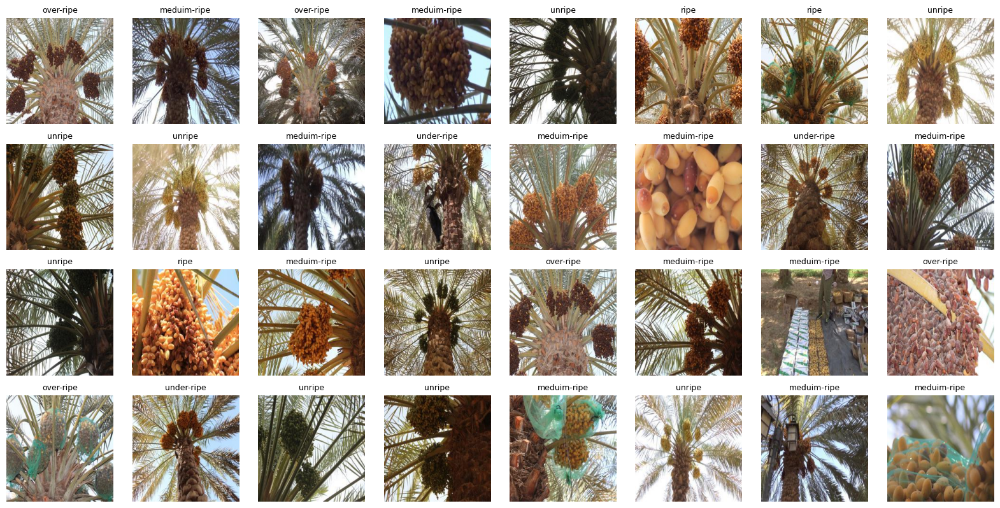

In [ ]:
import numpy as np, math
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1 import ImageGrid

y_int = np.argmax(y, axis=-1)

def show_grid(image_list, nrows, ncols, label_list=None, show_labels=False,
              savename=None, figsize=(10, 10), showaxis='off'):
    if type(image_list) is not list:
        if(image_list.shape[-1] == 1):
            image_list = [image_list[i, :, :, 0] for i in range(image_list.shape[0])]
        elif(image_list.shape[-1] == 3):
            image_list = [image_list[i, :, :, :] for i in range(image_list.shape[0])]
    fig = plt.figure(None, figsize, frameon=False)
    grid = ImageGrid(fig, 111, nrows_ncols=(nrows, ncols), axes_pad=0.3, share_all=True)
    for i in range(nrows * ncols):
        ax = grid[i]
        ax.imshow(image_list[i])
        ax.axis('off')
        if show_labels:
            ax.set_title(class_mapping[y_int[i]], fontsize=9)
    if savename is not None:
        plt.savefig(savename, bbox_inches='tight')

show_grid(x, 4, 8, label_list=y_int, show_labels=True, figsize=(20, 10))
plt.show()


## Baseline model: shallow CNN (authors' cells 20–24)
Two conv blocks (128→64 filters, 3×3, MaxPooling, Dropout 0.15), dense 32, softmax over 5 classes; Adam lr 1e-4. This is the paper's shallow baseline (~30 M parameters at 224×224 input).
**日本語**: 論紙の浅い CNN ベースライン（Conv 128/64 + Dropout 0.15 + Dense 32、Adam lr=1e-4）を定義します。

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

batch_size = 64          # kept from the authors' cell; generators already emit batch 32
num_classes = 5
image_size = 224
lr = 0.0001              # learning rate

base_model = Sequential(name='baseline_model')
base_model.add(Conv2D(128, (3, 3), padding='same', activation='relu',
                input_shape=(image_size, image_size, 3)))
base_model.add(MaxPooling2D(pool_size=(2, 2)))
base_model.add(Dropout(0.15))
base_model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
base_model.add(MaxPooling2D(pool_size=(2, 2)))
base_model.add(Dropout(0.15))
base_model.add(Flatten())
base_model.add(Dense(32, activation='relu'))
base_model.add(Dropout(0.15))
base_model.add(Dense(num_classes, activation='softmax'))
base_model.compile(Adam(learning_rate=lr), loss='CategoricalCrossentropy',
                   metrics=['accuracy'])
base_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     6,422,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,500,101 (24.80 MB)

 Trainable params: 6,500,101 (24.80 MB)

 Non-trainable params: 0 (0.00 B)

## Train the baseline (40 epochs)
Authors' cell 26: fit on the training generator with the test generator as validation for 40 epochs (the paper's protocol; the “validation_data” here is the 20% test split, as in the authors' notebook).
**日本語**: baseline を 40 エポック学習します。検証データは著者ノートブックと同様にテスト分割です。

In [ ]:
from tensorflow.keras.callbacks import TensorBoard
cb = TensorBoard()
base_history = base_model.fit(train_generator,
                              batch_size=batch_size,
                              epochs=40,
                              validation_data=val_generator,
                              callbacks=[cb])


Epoch 1/40


  1/245 ━━━━━━━━━━━━━━━━━━━━ 59:06 15s/step - accuracy: 0.1562 - loss: 1.6138

  2/245 ━━━━━━━━━━━━━━━━━━━━ 30s 124ms/step - accuracy: 0.1641 - loss: 1.7541

  3/245 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.1858 - loss: 1.7688

  4/245 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - accuracy: 0.2038 - loss: 1.7801

...

242/245 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8942 - loss: 0.2528

243/245 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8943 - loss: 0.2528

244/245 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8943 - loss: 0.2528

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8943 - loss: 0.2528

245/245 ━━━━━━━━━━━━━━━━━━━━ 35s 144ms/step - accuracy: 0.8956 - loss: 0.2516 - val_accuracy: 0.7891 - val_loss: 0.8073


## Baseline training curves and test evaluation
Authors' cells 28–30: loss/accuracy curves, then `evaluate` on the (unshuffled) test generator. **Expected: test accuracy well below the transfer-learning models; the paper reports 70.89%.**
**日本語**: baseline の学習曲線とテスト評価を表示します（論文では 70.89%）。

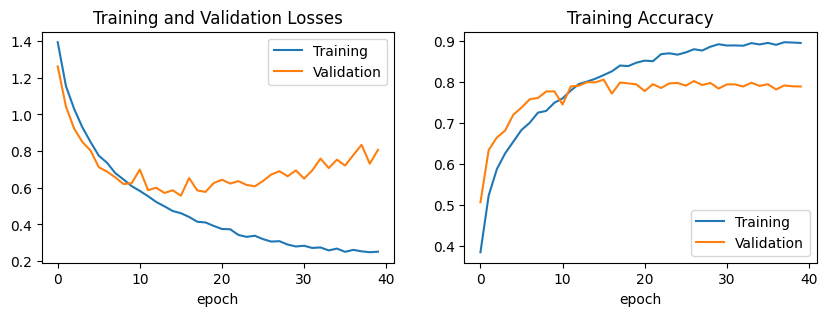

 1/62 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.8125 - loss: 0.3900

 2/62 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.8125 - loss: 0.4069 

 3/62 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.8021 - loss: 0.4279

 4/62 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.7852 - loss: 0.4505

 5/62 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7844 - loss: 0.4456

...

59/62 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7679 - loss: 0.7219

60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7682 - loss: 0.7235

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7685 - loss: 0.7249

62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.7891 - loss: 0.8073


Test loss: 0.8073425889015198 Test Acc: 0.7890704870223999


In [ ]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.plot(base_history.history['loss'])
plt.plot(base_history.history['val_loss'])
plt.legend(['Training', 'Validation'])
plt.title('Training and Validation Losses')
plt.xlabel('epoch')
plt.subplot(122)
plt.plot(base_history.history['accuracy'])
plt.plot(base_history.history['val_accuracy'])
plt.legend(['Training', 'Validation'])
plt.title('Training Accuracy')
plt.xlabel('epoch')
plt.show()

test_loss, test_acc = base_model.evaluate(val_generator)
print('Test loss: {} Test Acc: {}'.format(test_loss, test_acc))


## ResNet50V2 model with new head (authors' cells 33–37)
The authors import **ResNet50V2** (`weights='imagenet'`, `include_top=False`, `pooling='avg'`), freeze every layer, and append Flatten → Dense 16 (ReLU) → Dropout 0.15 → Dense 5 softmax, per the paper's fine-tuning description. Note the paper text says “ResNet50”; the pinned code uses the V2 variant — we follow the code.
**日本語**: 著者コードは ResNet50**V2** を使用しています（論文本文は ResNet50 と表記）。コードに従い V2 を凍結してヘッド (Dense16→Dropout→Dense5) を追加します。

In [ ]:
resnet_model = Sequential(name='resnet_model')
pretrained_model = tf.keras.applications.ResNet50V2(include_top=False,
                   input_shape=(image_size, image_size, 3),
                   pooling='avg', classes=5,
                   weights='imagenet')
for layer in pretrained_model.layers:
        layer.trainable = False
resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(16, activation='relu'))
resnet_model.add(Dropout(0.15))
resnet_model.add(Dense(5, activation='softmax'))
resnet_model.summary()


       0/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   49152/94668760 ━━━━━━━━━━━━━━━━━━━━ 7:23 5us/step

   81920/94668760 ━━━━━━━━━━━━━━━━━━━━ 8:14 5us/step

  114688/94668760 ━━━━━━━━━━━━━━━━━━━━ 6:36 4us/step

  147456/94668760 ━━━━━━━━━━━━━━━━━━━━ 5:41 4us/step

...

Model: "resnet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │        32,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,669 (90.02 MB)

 Trainable params: 32,869 (128.39 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

## Train ResNet50V2 (40 epochs, Adam 1e-3)
Authors' cell 39. Only the small head trains (the backbone is frozen), but every batch still passes through the full backbone. **Expected ~15–25 min on T4**; ImageNet weights download on first use.
**日本語**: ResNet50V2 を 40 エポック学習します（T4 で約 15–25 分を見込んでください）。

In [ ]:
resnet_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])
history = resnet_model.fit(train_generator, validation_data=val_generator, epochs=40)


Epoch 1/40


  1/245 ━━━━━━━━━━━━━━━━━━━━ 56:57 14s/step - accuracy: 0.0938 - loss: 2.0799

  2/245 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - accuracy: 0.1875 - loss: 1.9487

  3/245 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - accuracy: 0.2326 - loss: 1.8705

  4/245 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.2487 - loss: 1.8274 

...

241/245 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9566 - loss: 0.1182

242/245 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9566 - loss: 0.1182

243/245 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9566 - loss: 0.1182

244/245 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9566 - loss: 0.1181

245/245 ━━━━━━━━━━━━━━━━━━━━ 28s 116ms/step - accuracy: 0.9583 - loss: 0.1159 - val_accuracy: 0.8672 - val_loss: 0.5166


## ResNet50V2 curves and test evaluation
Authors' cell 41. **Expected: test accuracy ≈ 86% (paper Table 1: 86.41%).**
**日本語**: ResNet50V2 の学習曲線とテスト評価（論文では 86.41%）を表示します。

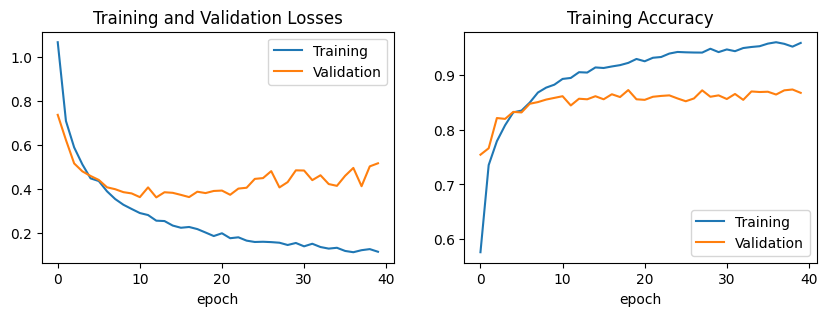

 1/62 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 1.0000 - loss: 0.0125

 2/62 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.9922 - loss: 0.0410 

 3/62 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.9740 - loss: 0.0951

 4/62 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.9668 - loss: 0.1212

 5/62 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.9634 - loss: 0.1345

...

59/62 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8957 - loss: 0.3730

60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8952 - loss: 0.3755

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8948 - loss: 0.3779

62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.8672 - loss: 0.5166


Resnet model - Test loss: 0.5165588855743408 Test Acc: 0.8672114610671997


In [ ]:
fig = plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training', 'Validation'])
plt.title('Training and Validation Losses')
plt.xlabel('epoch')
plt.subplot(122)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training', 'Validation'])
plt.title('Training Accuracy')
plt.xlabel('epoch')
plt.show()

test_loss, test_acc = resnet_model.evaluate(val_generator)
print('Resnet model - Test loss: {} Test Acc: {}'.format(test_loss, test_acc))


## InceptionV3 model with new head (authors' cells 43–44)
Frozen `InceptionV3` (ImageNet, `include_top=False`) + Flatten → Dense 5 softmax; Adam lr 1e-4 for 40 epochs. The paper notes this model overfits (100% train / 85.24% test).
**日本語**: 凍結 InceptionV3 + Dense5 を Adam lr=1e-4 で 40 エポック学習します（論文では過学習が報告されています）。

In [ ]:
pre_incept = tf.keras.applications.InceptionV3(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet')
for layer in pre_incept.layers:
        layer.trainable = False
inc_model = Sequential(name="Inception_model")
inc_model.add(pre_incept)
inc_model.add(Flatten())
inc_model.add(Dense(5, activation='softmax'))
inc_model.summary()

inc_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
inc_history = inc_model.fit(train_generator, validation_data=val_generator, epochs=40)


       0/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   32768/87910968 ━━━━━━━━━━━━━━━━━━━━ 2:25 2us/step

   49152/87910968 ━━━━━━━━━━━━━━━━━━━━ 6:45 5us/step

   81920/87910968 ━━━━━━━━━━━━━━━━━━━━ 7:30 5us/step

  114688/87910968 ━━━━━━━━━━━━━━━━━━━━ 6:03 4us/step

...

242/245 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 6.9564e-04

243/245 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 6.9571e-04

244/245 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 6.9577e-04

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 6.9582e-04

245/245 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accuracy: 1.0000 - loss: 7.1030e-04 - val_accuracy: 0.8570 - val_loss: 0.6520


## InceptionV3 evaluation and curves
Authors' cell 45. **Expected: near-perfect training accuracy with ~85% test accuracy (paper: 85.24%).**
**日本語**: InceptionV3 のテスト評価と学習曲線を表示します（論文では 85.24%）。

 1/62 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.9375 - loss: 0.0663

 2/62 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9141 - loss: 0.1795 

 3/62 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.9010 - loss: 0.2308

 4/62 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8887 - loss: 0.2694

 5/62 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8872 - loss: 0.2774

...

59/62 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8522 - loss: 0.6188

60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8523 - loss: 0.6194

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8524 - loss: 0.6200

62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.8570 - loss: 0.6520


Inception model - Test loss: 0.6520238518714905 Test Acc: 0.8569969534873962


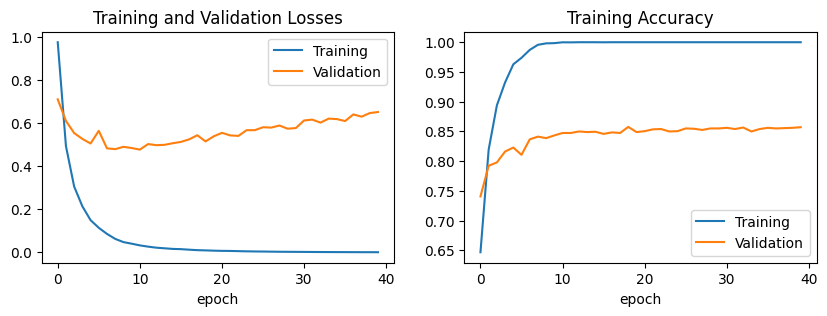

In [ ]:
test_loss, test_acc = inc_model.evaluate(val_generator)
print('Inception model - Test loss: {} Test Acc: {}'.format(test_loss, test_acc))

fig = plt.figure(figsize=(10, 3))
plt.subplot(121)
plt.plot(inc_history.history['loss'])
plt.plot(inc_history.history['val_loss'])
plt.legend(['Training', 'Validation'])
plt.title('Training and Validation Losses')
plt.xlabel('epoch')
plt.subplot(122)
plt.plot(inc_history.history['accuracy'])
plt.plot(inc_history.history['val_accuracy'])
plt.legend(['Training', 'Validation'])
plt.title('Training Accuracy')
plt.xlabel('epoch')
plt.show()


## Evaluation helpers: confusion matrix + classification report (authors' cell 48)
`cm_cr` predicts on the unshuffled test generator, prints sklearn's classification report, and renders the confusion matrix as a heatmap.
**日本語**: 混同行列と classification report を描く著者の関数を定義します。

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def cm_cr(test_gen, model):
    predictions = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(predictions, axis=-1)
    y_true = test_gen.classes
    class_names = list(test_gen.class_indices.keys())
    cm = confusion_matrix(y_true, y_pred)
    clr = classification_report(y_true, y_pred, digits=4)
    print("Classification Report:\n----------------------\n", clr)
    fig = plt.figure(figsize=(7, 5))
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, fmt='g')
    ax.set_xlabel('Predicted', fontsize=20)
    ax.xaxis.set_label_position('bottom')
    plt.xticks(rotation=90)
    ax.xaxis.set_ticklabels(class_names, fontsize=10)
    ax.xaxis.tick_bottom()
    ax.set_ylabel('True', fontsize=20)
    ax.yaxis.set_ticklabels(class_names, fontsize=10)
    plt.yticks(rotation=0)
    plt.title('Refined Confusion Matrix', fontsize=20)
    plt.show()


## ROC helper: per-class, micro- and macro-average (authors' cell 51)
`multiple_roc` one-hot-encodes the true labels and plots per-class ROC plus micro/macro averages with AUC values. The authors' `from scipy import interp` no longer exists in modern SciPy (it was an alias of `numpy.interp`); the numerically identical `np.interp` is used.
**日本語**: クラス別・micro/macro 平均 ROC を描く著者の関数を定義します。新しい SciPy では `scipy.interp` が削除されたため、同一関数の `np.interp` を使用します。

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_curve, auc
from itertools import cycle

def multiple_roc(test_gen, model):
    n_classes = 5
    y = test_gen.classes
    enc = OneHotEncoder()
    y_test = enc.fit_transform(y[:, np.newaxis]).toarray()
    y_score = model.predict(test_gen)
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    plt.figure(figsize=(7, 6))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.4f})'.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    plt.plot(fpr["macro"], tpr["macro"],
             label='macro-average ROC curve (area = {0:0.4f})'.format(roc_auc["macro"]),
             color='navy', linestyle=':', linewidth=4)
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'darkgreen', 'deeppink'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.4f})'.format(i, roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic to multi-class')
    plt.legend(loc="lower right")
    plt.show()


## Baseline evaluation: confusion matrix and ROC
Authors' cells 53/55 applied to the trained baseline.
**日本語**: baseline の混同行列と ROC を表示します。

Classification Report:
----------------------
               precision    recall  f1-score   support

           0     0.7668    0.8000    0.7831       670
           1     0.8944    0.6851    0.7759       235
           2     0.8720    0.5909    0.7044       242
           3     0.6757    0.7225    0.6983       346
           4     0.8349    0.9785    0.9010       465

    accuracy                         0.7891      1958
   macro avg     0.8087    0.7554    0.7725      1958
weighted avg     0.7952    0.7891    0.7855      1958



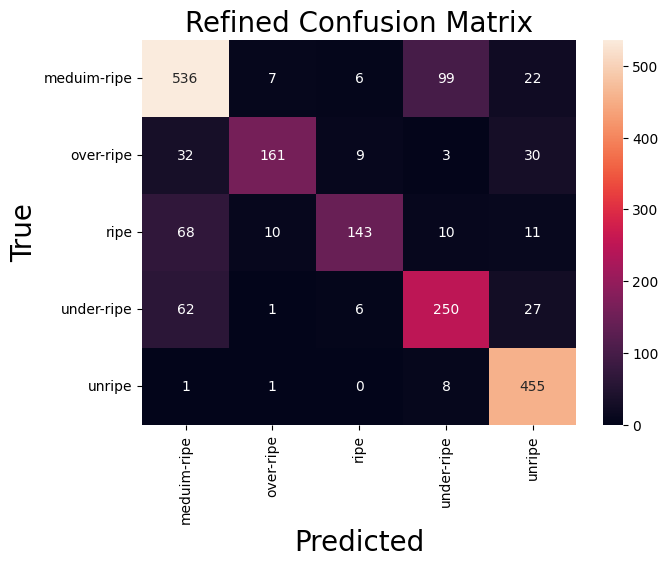

 1/62 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step

 2/62 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step 

 3/62 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step

 4/62 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step

 5/62 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step

...

58/62 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

59/62 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step


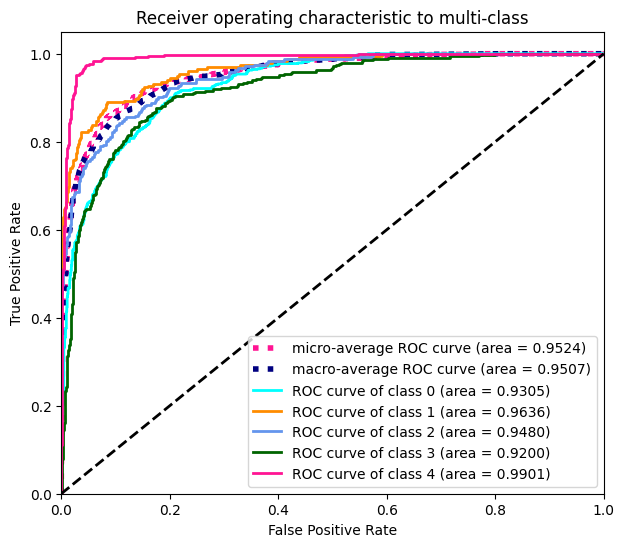

In [ ]:
cm_cr(val_generator, base_model)
multiple_roc(val_generator, base_model)


## ResNet50V2 evaluation: confusion matrix and ROC
Authors' cells 57/59. **Expected: ResNet50 leads most metrics (paper micro-AUC 0.9812).**
**日本語**: ResNet50V2 の混同行列と ROC（論文 micro-AUC 0.9812）を表示します。

Classification Report:
----------------------
               precision    recall  f1-score   support

           0     0.8286    0.9164    0.8703       670
           1     0.9009    0.8511    0.8753       235
           2     0.8943    0.8388    0.8657       242
           3     0.8557    0.7370    0.7919       346
           4     0.9064    0.9161    0.9112       465

    accuracy                         0.8672      1958
   macro avg     0.8772    0.8519    0.8629      1958
weighted avg     0.8687    0.8672    0.8662      1958



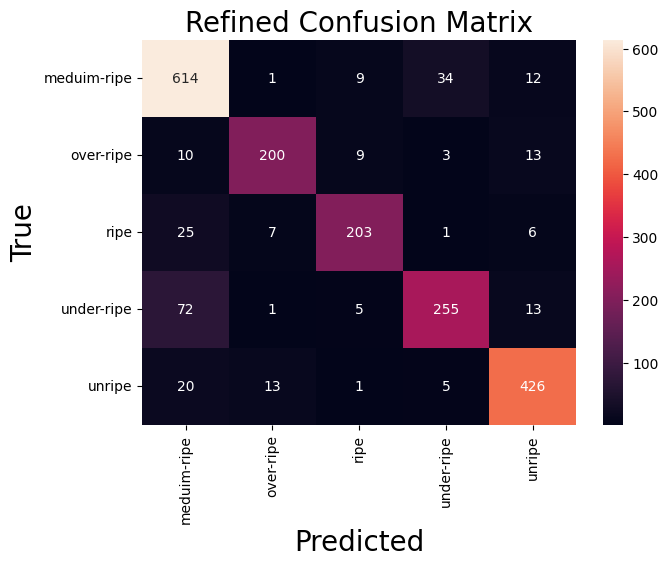

 1/62 ━━━━━━━━━━━━━━━━━━━━ 12s 205ms/step

 2/62 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step  

 3/62 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step

 4/62 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step

 5/62 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step

...

58/62 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

59/62 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step


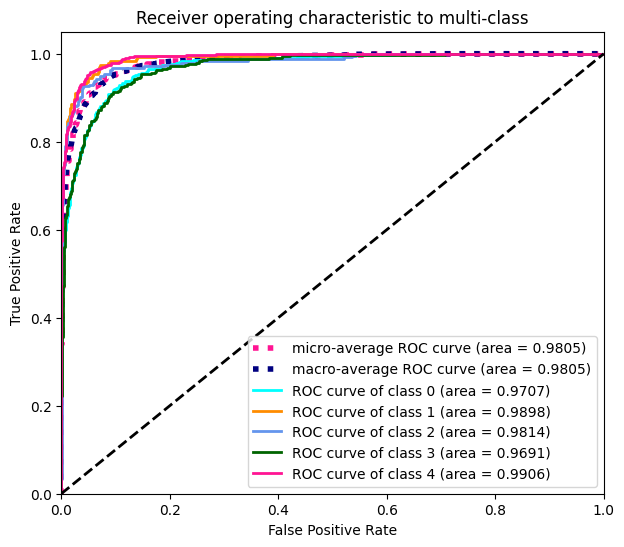

In [ ]:
cm_cr(val_generator, resnet_model)
multiple_roc(val_generator, resnet_model)


## InceptionV3 evaluation: confusion matrix and ROC
Authors' cells 61/63.
**日本語**: InceptionV3 の混同行列と ROC を表示します。

Classification Report:
----------------------
               precision    recall  f1-score   support

           0     0.8201    0.8642    0.8416       670
           1     0.9256    0.8468    0.8844       235
           2     0.9128    0.8223    0.8652       242
           3     0.8153    0.7399    0.7758       346
           4     0.8812    0.9570    0.9175       465

    accuracy                         0.8570      1958
   macro avg     0.8710    0.8460    0.8569      1958
weighted avg     0.8579    0.8570    0.8560      1958



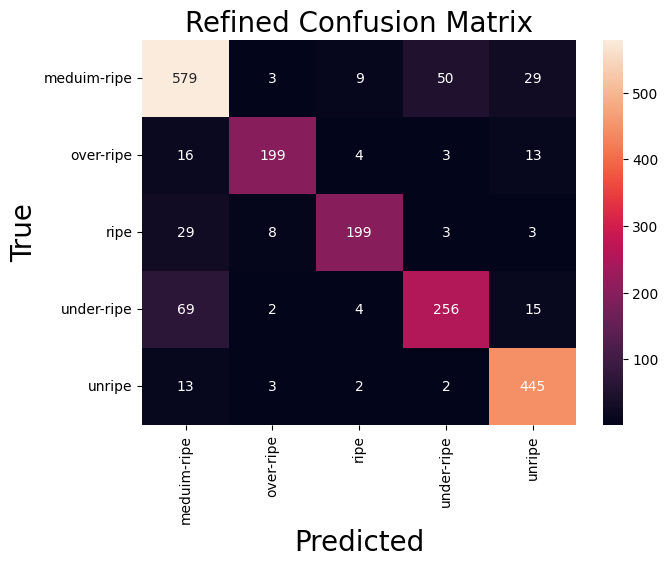

 1/62 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step

 2/62 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step  

 3/62 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step

 4/62 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step

 5/62 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step

...

58/62 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

59/62 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step


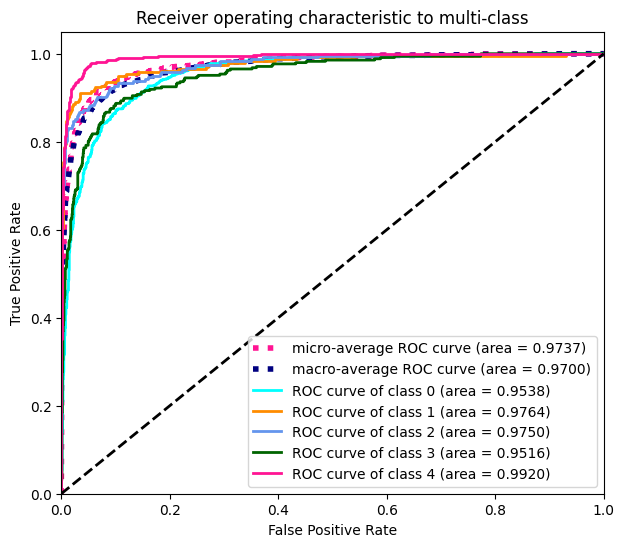

In [ ]:
cm_cr(val_generator, inc_model)
multiple_roc(val_generator, inc_model)


## Three-model ROC comparison (authors' cells 65–66)
Micro-averaged ROC of all three models on one axis.
**日本語**: 3 モデルの micro 平均 ROC を重ねて比較します。

 1/62 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step

 2/62 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step 

 3/62 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step

 4/62 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step

 5/62 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step

...

58/62 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

59/62 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step


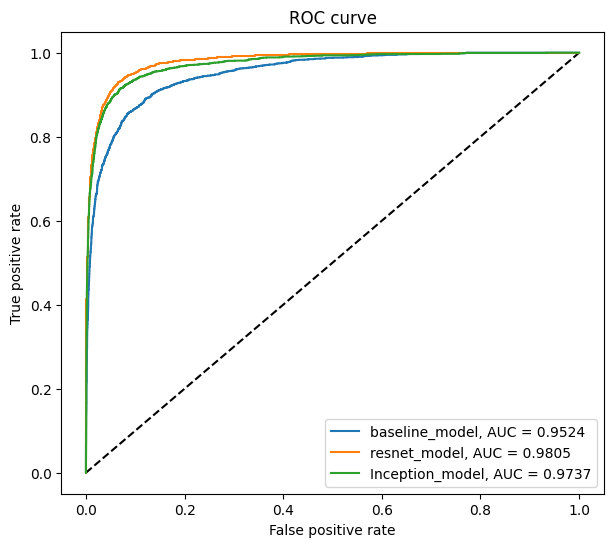

In [ ]:
def roc(test_gen, models):
    y = test_gen.classes
    enc = OneHotEncoder()
    Y = enc.fit_transform(y[:, np.newaxis]).toarray()
    plt.figure(figsize=(7, 6))
    plt.plot([0, 1], [0, 1], 'k--')
    for model in models:
        yfit = model.predict(test_gen)
        fpr, tpr, _ = roc_curve(Y.ravel(), yfit.ravel())
        plt.plot(fpr, tpr, label='{}, AUC = {:.4f}'.format(model.name, auc(fpr, tpr)))
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC curve')
    plt.legend()

models = [base_model, resnet_model, inc_model]
roc(val_generator, models)


## Result summary versus the paper
Small table comparing this run's measured test accuracy with the paper's Table 1 values (0.7089 / 0.8641 / 0.8524), plus a CSV export. Exact equality is **not expected**: the run uses the authors' split seed on the released data, but framework version differences and GPU nondeterminism change results.
**日本語**: 本ランのテスト精度と論文 Table 1 の値を比較表にして CSV 出力します（環境差により完全一致は期待しません）。

In [ ]:
import pandas as pd
paper = {'baseline_model': 0.7089, 'resnet_model': 0.8641, 'Inception_model': 0.8524}
rows = []
for m in models:
    _, acc = m.evaluate(val_generator, verbose=0)
    rows.append({'model': m.name, 'test_accuracy_this_run': round(acc, 4),
                 'test_accuracy_paper_table1': paper[m.name],
                 'difference': round(acc - paper[m.name], 4)})
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('/content/results_summary.csv', index=False)
print("saved /content/results_summary.csv")


          model  test_accuracy_this_run  test_accuracy_paper_table1  difference
 baseline_model                  0.7891                      0.7089      0.0802
   resnet_model                  0.8672                      0.8641      0.0031
Inception_model                  0.8570                      0.8524      0.0046
saved /content/results_summary.csv


## Training-curve comparison of the three models
Authors' closing cell 71: losses (left) and accuracies (right) for all models, training vs validation.
**日本語**: 3 モデルの学習曲線を著者の最終セルと同じ形式で比較します。

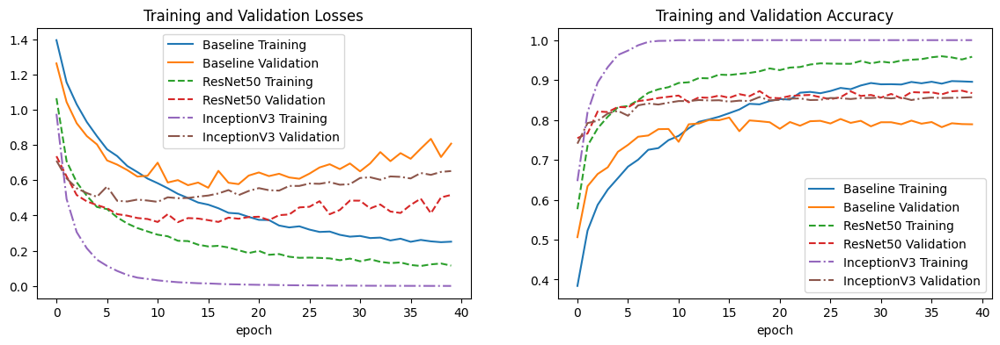

In [ ]:
fig = plt.figure(figsize=(14, 4))
plt.subplot(121)
plt.plot(base_history.history['loss'], '-')
plt.plot(base_history.history['val_loss'], '-')
plt.plot(history.history['loss'], '--')
plt.plot(history.history['val_loss'], '--')
plt.plot(inc_history.history['loss'], '-.')
plt.plot(inc_history.history['val_loss'], '-.')
plt.legend(['Baseline Training', 'Baseline Validation',
            'ResNet50 Training', 'ResNet50 Validation',
            'InceptionV3 Training', 'InceptionV3 Validation'])
plt.title('Training and Validation Losses')
plt.xlabel('epoch')
plt.subplot(122)
plt.plot(base_history.history['accuracy'], '-')
plt.plot(base_history.history['val_accuracy'], '-')
plt.plot(history.history['accuracy'], '--')
plt.plot(history.history['val_accuracy'], '--')
plt.plot(inc_history.history['accuracy'], '-.')
plt.plot(inc_history.history['val_accuracy'], '-.')
plt.legend(['Baseline Training', 'Baseline Validation',
            'ResNet50 Training', 'ResNet50 Validation',
            'InceptionV3 Training', 'InceptionV3 Validation'])
plt.title('Training and Validation Accuracy')
plt.xlabel('epoch')
plt.show()


## Interpretation, differences from the paper, and validation record

- **What was executed**: the authors' full pipeline on their released data — public `gdown` download of `data3.zip`, deterministic `splitfolders` 80/20 split (seed 12345), 224×224 / 1/255 generators (batch 32), and 40-epoch training of the three pinned architectures, followed by the authors' own confusion-matrix and ROC evaluation. Executed end-to-end on a fresh Colab **T4 GPU** runtime (see report for the validation date).
- **Comparison with the paper**: the paper itself is internally inconsistent (its Experiments intro gives 77.5%/85.9%/84.5% while model sections and Table 1 give 70.89%/86.41%/85.24%); we compare against Table 1. Differences from our run are expected from TF version, GPU nondeterminism, and any archive-level differences; the split itself is reproducible from the released zip + seed 12345.
- **Known code/paper discrepancies**: the paper says "ResNet50" but the pinned code uses `ResNet50V2`; the paper's EfficientNet branch (<50% test accuracy) is mentioned in the discussion only and is not part of the released notebook — it is out of scope here.
- **Adaptations**: gdown download (no author Drive mount), `Adam(learning_rate=…)`, no ignored `batch_size` in `fit`, `visualkeras` section omitted.
- **Limitations**: one training run per model; no hyperparameter sweeps or dataset-level statistics; reported figures are from the authors' hardware/software era (2025, TF 2.x of that time).
- **License note**: the repository has **no license file**; code is reused here solely for scholarly reproduction with citation.

**日本語**: 本ノートブックは著者のパイプラインをそのまま T4 GPU で実行したものです。論文内で数値に不整合があるため Table 1 の値を参照値とします。リポジトリにライセンスファイルはなく、引用付きの学術再現目的での利用です。

## References

- Han, M. & Yi, C. (2025). *Deep Convolutional Neural Networks for Palm Fruit Maturity Classification.* arXiv:2502.20223v1.
- Altaheri, H. et al. (2019). *Date Fruit Dataset for Automated Harvesting and Visual Yield Estimation.* IEEE DataPort (original dataset the authors modified).
- Pinned author code: `mingqianghan/PalmFruitMaturity-CNN` commit `de096ccc89b2f8ca99d7e31beab8aba95b4188db` (README + `code.ipynb`).